## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import warnings
from google.colab import drive
drive.mount('/content/drive')
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load data
path = '/content/drive/MyDrive/amazon_clean_dataset/eda_ready.csv'
df = pd.read_csv(path, low_memory=False)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Log-transform skewed columns used as controls
df['log_rating_number'] = np.log1p(df['rating_number'].fillna(0))
df['log_review_length'] = np.log1p(df['review_length'].fillna(0))
df['log_helpful_vote']  = np.log1p(df['helpful_vote'].fillna(0))

# anchor_delta: how far the individual rating deviates from the product average
df['anchor_delta'] = df['rating'] - df['average_rating']

# verified_purchase as boolean integer (0/1)
df['verified_int'] = df['verified_purchase'].astype(bool).astype(int)

print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
df[['rating', 'average_rating', 'verified_purchase', 'price',
    'review_length', 'helpful_vote', 'anchor_delta']].describe().round(2)

Loaded 365,944 rows × 30 columns


,rating,average_rating,price,review_length,helpful_vote,anchor_delta
count,365944.00,365944.00,250900.00,365820.00,365944.00,365944.00
mean,3.80,4.17,479.78,318.64,2.13,-0.37
std,1.59,0.42,478.43,535.80,19.71,1.53
min,1.00,1.00,5.99,1.00,0.00,-4.00
25%,3.00,4.00,169.00,64.00,0.00,-1.50
50%,5.00,4.20,319.00,160.00,0.00,0.40
75%,5.00,4.40,637.00,361.00,1.00,0.70
max,5.00,5.00,6999.99,24527.00,6386.00,4.00


## Hypothesis 3: Longer and lower-rated reviews receive more helpful votes

**H₀**: Review length and star rating do not predict helpful votes  
**H₁**: Longer reviews and negative reviews (1–2 stars) attract more helpful votes  

*Intuition*: Detailed negative reviews provide specific warnings that readers find useful.

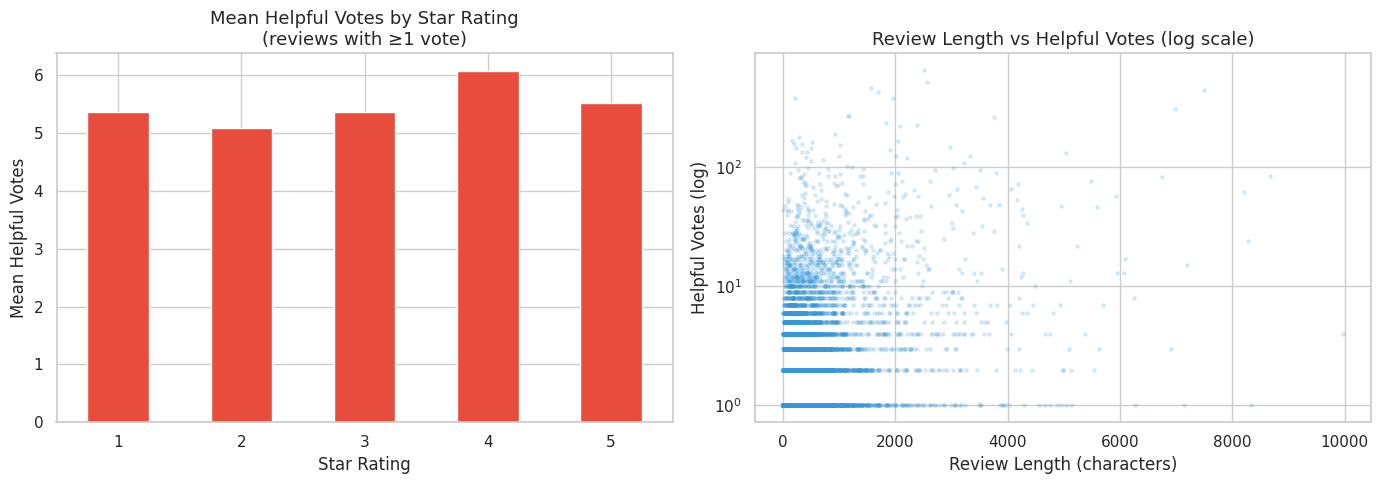

In [ ]:
# 3a. Helpful votes by star rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean helpful votes per rating (only reviews that received at least 1 vote)
hv_pos = df[df['helpful_vote'] > 0]
hv_by_rating = hv_pos.groupby('rating')['helpful_vote'].mean()

hv_by_rating.plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].set_title('Mean Helpful Votes by Star Rating\n(reviews with ≥1 vote)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Mean Helpful Votes')
axes[0].tick_params(axis='x', rotation=0)

# Scatter: review_length vs helpful_vote (log scale, sample)
sample = hv_pos.sample(min(8000, len(hv_pos)), random_state=42)
axes[1].scatter(sample['review_length'], sample['helpful_vote'],
                alpha=0.15, s=6, color='#3498db')
axes[1].set_yscale('log')
axes[1].set_title('Review Length vs Helpful Votes (log scale)')
axes[1].set_xlabel('Review Length (characters)')
axes[1].set_ylabel('Helpful Votes (log)')

plt.tight_layout()
plt.show()

In [ ]:
# 3b. Spearman correlation — review_length vs helpful_vote
# Spearman is more appropriate than Pearson here (heavy right skew on both)
df_hv = df[['review_length','helpful_vote', 'rating', 'log_review_length']].dropna()

rho_length, p_length = stats.spearmanr(
    df_hv['review_length'], df_hv['helpful_vote']
)
rho_rating, p_rating = stats.spearmanr(
    df_hv['rating'], df_hv['helpful_vote']
)

print('Spearman correlations with helpful_vote:')
print(f'  review_length  : ρ = {rho_length:.4f}  (p = {p_length:.4e})')
print(f'  rating         : ρ = {rho_rating:.4f}  (p = {p_rating:.4e})')
print()
print('|ρ| guide: <0.1 negligible, 0.1-0.3 weak, 0.3-0.5 moderate, >0.5 strong')

Spearman correlations with helpful_vote:
  review_length  : ρ = 0.3610  (p = 0.0000e+00)
  rating         : ρ = -0.1284  (p = 0.0000e+00)

|ρ| guide: <0.1 negligible, 0.1-0.3 weak, 0.3-0.5 moderate, >0.5 strong


In [ ]:
#3c. Mann-Whitney U — do negative reviews get more helpful votes?
neg_votes = df[df['rating'] <= 2]['helpful_vote'].dropna()
pos_votes = df[df['rating'] >= 4]['helpful_vote'].dropna()

stat, p = stats.mannwhitneyu(neg_votes, pos_votes, alternative='greater')
n1, n2  = len(neg_votes), len(pos_votes)
r_rb    = 1 - (2 * stat) / (n1 * n2)

print('Negative (1-2stars) vs Positive (4-5stars) helpful votes:')
print(f'  Median negative : {neg_votes.median():.1f}')
print(f'  Median positive : {pos_votes.median():.1f}')
print(f'  Mann-Whitney p  : {p:.4e}')
print(f'  Effect size (r) : {r_rb:.4f}')

Negative (1-2stars) vs Positive (4-5stars) helpful votes:
  Median negative : 0.0
  Median positive : 0.0
  Mann-Whitney p  : 0.0000e+00
  Effect size (r) : -0.1306


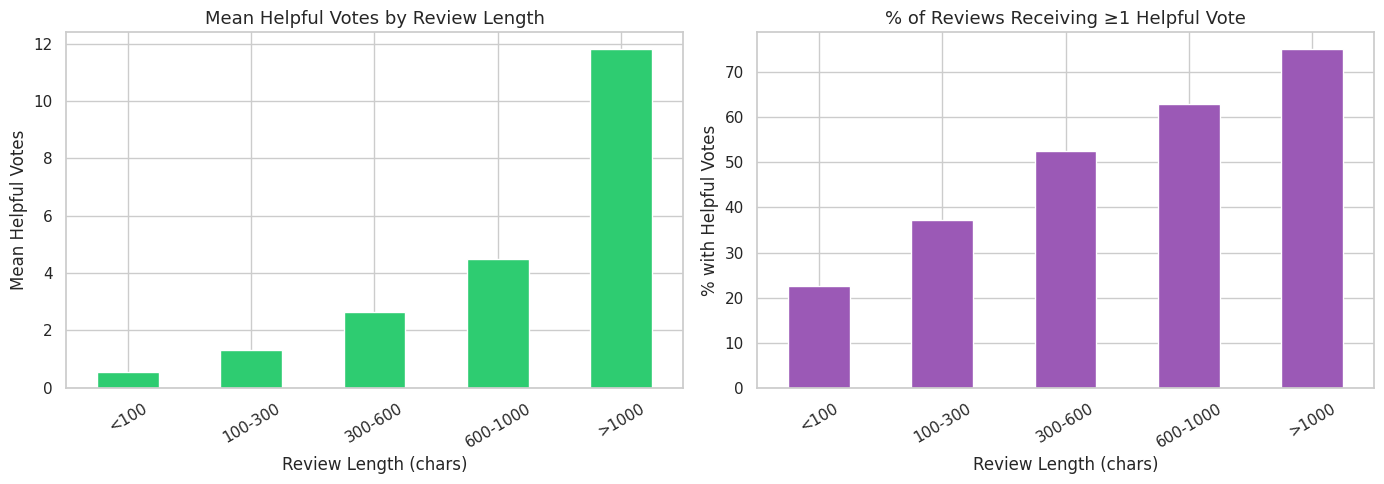

length_bucket  mean_helpful  pct_voted
         <100      0.551982  22.534744
      100-300      1.326379  37.120086
      300-600      2.655609  52.550247
     600-1000      4.488449  63.035899
        >1000     11.807117  75.080671


In [ ]:
# 3d. Helpful vote rate by review length bucket
df['length_bucket'] = pd.cut(
    df['review_length'],
    bins=[0, 100, 300, 600, 1000, 99999],
    labels=['<100', '100-300', '300-600', '600-1000', '>1000']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bucket_stats = df.groupby('length_bucket', observed=True).agg(
    mean_helpful=('helpful_vote', 'mean'),
    pct_voted=('helpful_vote', lambda x: (x > 0).mean() * 100)
).reset_index()

bucket_stats.plot(x='length_bucket', y='mean_helpful', kind='bar',
                  ax=axes[0], color='#2ecc71', legend=False)
axes[0].set_title('Mean Helpful Votes by Review Length')
axes[0].set_xlabel('Review Length (chars)')
axes[0].set_ylabel('Mean Helpful Votes')
axes[0].tick_params(axis='x', rotation=30)

bucket_stats.plot(x='length_bucket', y='pct_voted', kind='bar',
                  ax=axes[1], color='#9b59b6', legend=False)
axes[1].set_title('% of Reviews Receiving ≥1 Helpful Vote')
axes[1].set_xlabel('Review Length (chars)')
axes[1].set_ylabel('% with Helpful Votes')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(bucket_stats.to_string(index=False))

### H3 Conclusion

**Result: Partially Supported (mixed evidence)**

The data partially supports H₁:

- **Review length** has a **moderate positive correlation** with helpful votes (Spearman ρ = 0.361, p ≈ 0), confirming that longer reviews are genuinely more useful to readers. Reviews over 1,000 characters average **11.8 helpful votes** and a 75% vote rate, vs. only 0.55 votes for short reviews (<100 characters).
- **Star rating** has a **weak negative correlation** with helpful votes (ρ = −0.128, p ≈ 0) — lower-rated reviews attract slightly more helpful votes, but the effect is small.
- The Mann-Whitney comparison of negative (1–2★) vs. positive (4–5★) reviews shows a statistically significant but **practically negligible** difference (r = −0.131), with both groups sharing a median of 0 helpful votes.

**Takeaway:** Review **length is the dominant predictor** of helpfulness. While negative reviews are marginally more helpful than positive ones, the effect is too small to be actionable. The hypothesis is partially confirmed — length strongly holds, but the rating-direction effect is weak.


## Hypothesis 4: Product popularity influences individual rating behavior

**H₀**: Products with few vs many reviews produce the same rating distribution  
**H₁**: More popular products (higher review count) receive higher average individual ratings  

*Intuition*: Popular products may benefit from selection bias (people buy what's already well-reviewed) or social proof (seeing 4.5 stars nudges reviewers upward).

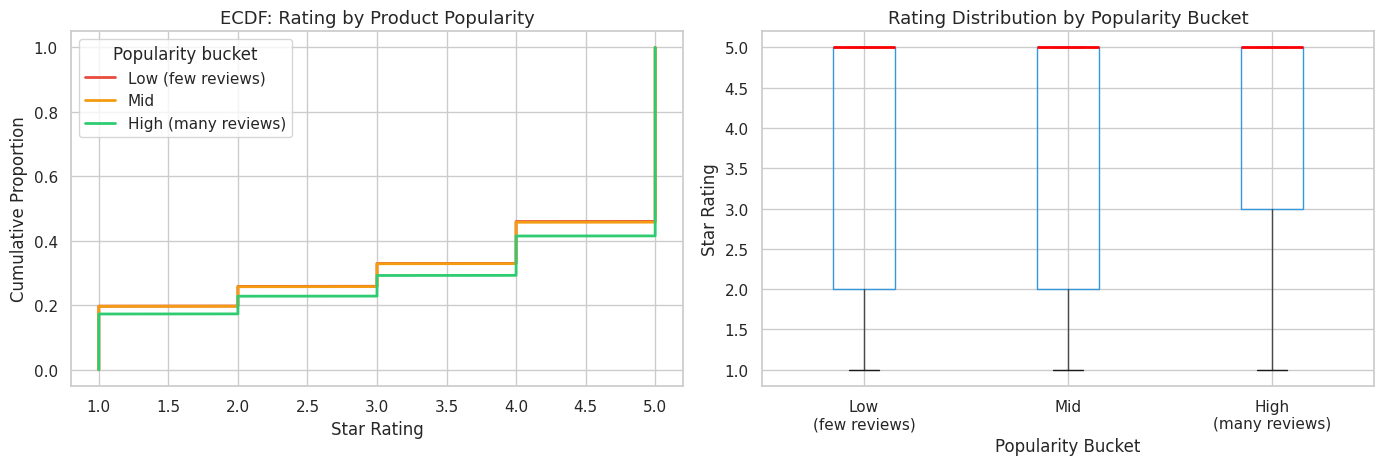

Median rating and review length by popularity bucket:
                      rating  review_length
pop_bucket                                 
Low\n(few reviews)       5.0          174.0
Mid                      5.0          163.0
High\n(many reviews)     5.0          146.0


In [ ]:
# 4a. Split into popularity buckets
df['pop_bucket'] = pd.qcut(
    df['rating_number'],
    q=3,
    labels=['Low\n(few reviews)', 'Mid', 'High\n(many reviews)']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution per bucket
for bucket, color in zip(['Low\n(few reviews)', 'Mid', 'High\n(many reviews)'],
                          ['#e74c3c', '#f39c12', '#2ecc71']):
    subset = df[df['pop_bucket'] == bucket]['rating']
    x = np.sort(subset)
    y = np.arange(1, len(x) + 1) / len(x)
    axes[0].plot(x, y, label=bucket.replace('\n', ' '),
                 color=color, linewidth=2)
axes[0].set_title('ECDF: Rating by Product Popularity')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Cumulative Proportion')
axes[0].legend(title='Popularity bucket')

# Box plot
df.boxplot(column='rating', by='pop_bucket', ax=axes[1],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Rating Distribution by Popularity Bucket')
axes[1].set_xlabel('Popularity Bucket')
axes[1].set_ylabel('Star Rating')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Median rating and review length by popularity bucket:')
print(df.groupby('pop_bucket', observed=True)[['rating', 'review_length']]
      .median().round(2))

**Note**: Popularity has almost no effect on how people rate products. Whether a product has few or many reviews, the rating distribution is essentially the same

In [ ]:
# 4b. Kruskal-Wallis test across popularity buckets
groups = [
    g['rating'].values
    for _, g in df.groupby('pop_bucket', observed=True)
]
kw_stat, kw_p = stats.kruskal(*groups)

# Effect size: eta-squared (η²)
n_total = sum(len(g) for g in groups)
k       = len(groups)
eta_sq  = (kw_stat - k + 1) / (n_total - k)

print(f'Kruskal-Wallis H : {kw_stat:.2f}')
print(f'P-value          : {kw_p:.4e}')
print(f'η² (effect size) : {eta_sq:.4f}  (<0.01 small, 0.01-0.06 medium, >0.14 large)')
print()

# Post-hoc pairwise Mann-Whitney with Bonferroni correction
bucket_labels = df['pop_bucket'].cat.categories.tolist()
print('Post-hoc pairwise Mann-Whitney (Bonferroni corrected, α=0.05/3=0.017):')
from itertools import combinations
pairs = list(combinations(range(len(groups)), 2))
for i, j in pairs:
    s, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
    n1, n2 = len(groups[i]), len(groups[j])
    r = 1 - (2 * s) / (n1 * n2)
    sig = '✓ sig' if p < 0.017 else '✗ ns'
    print(f'  {bucket_labels[i]!r:30} vs {bucket_labels[j]!r:30}  '
          f'p={p:.4e}  r={r:.4f}  {sig}')

Kruskal-Wallis H : 656.07
P-value          : 3.4399e-143
η² (effect size) : 0.0018  (<0.01 small, 0.01-0.06 medium, >0.14 large)

Post-hoc pairwise Mann-Whitney (Bonferroni corrected, α=0.05/3=0.017):
  'Low\n(few reviews)'           vs 'Mid'                           p=3.5990e-01  r=0.0020  ✗ ns
  'Low\n(few reviews)'           vs 'High\n(many reviews)'          p=2.3641e-114  r=0.0479  ✓ sig
  'Mid'                          vs 'High\n(many reviews)'          p=3.5203e-105  r=0.0459  ✓ sig


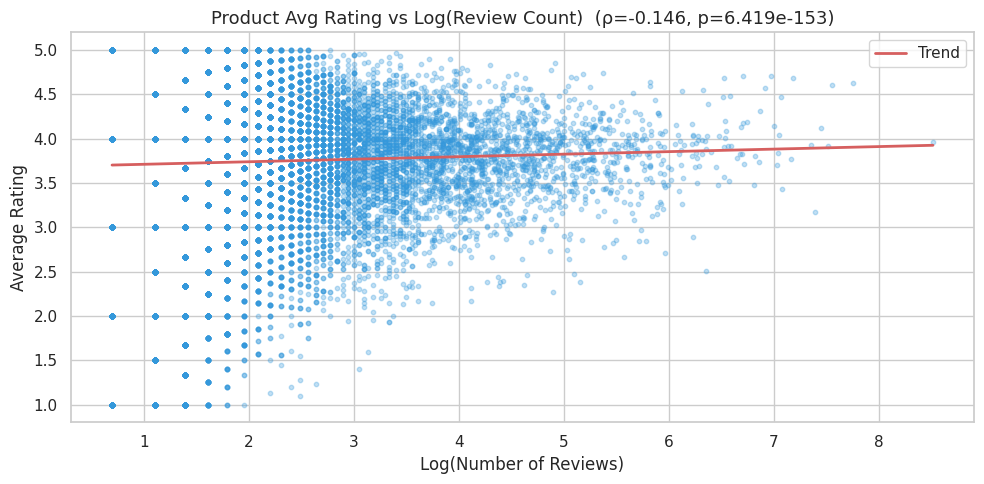

Spearman ρ = -0.1459  (p = 6.4187e-153)
Popularity–rating correlation is negative and weak


In [ ]:
#4c. Continuous view — rating vs log(rating_number)
product_level = (
    df.groupby('parent_asin')
    .agg(avg_rating=('rating', 'mean'),
         review_count=('rating', 'count'),
         avg_sentiment=('vader_sentiment', 'mean'))
    .reset_index()
)
product_level['log_review_count'] = np.log1p(product_level['review_count'])

rho, p = stats.spearmanr(
    product_level['log_review_count'],
    product_level['avg_rating']
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(product_level['log_review_count'], product_level['avg_rating'],
           alpha=0.3, s=10, color='#3498db')

# Numpy polyfit trend (no statsmodels)
coeffs = np.polyfit(product_level['log_review_count'],
                    product_level['avg_rating'], 1)
x_line = np.linspace(product_level['log_review_count'].min(),
                     product_level['log_review_count'].max(), 100)
ax.plot(x_line, np.polyval(coeffs, x_line), 'r-', linewidth=2, label='Trend')
ax.set_title(f'Product Avg Rating vs Log(Review Count)  (ρ={rho:.3f}, p={p:.3e})')
ax.set_xlabel('Log(Number of Reviews)')
ax.set_ylabel('Average Rating')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Spearman ρ = {rho:.4f}  (p = {p:.4e})')
print('Popularity–rating correlation is', 'positive' if rho > 0 else 'negative',
      'and', 'weak' if abs(rho) < 0.3 else 'moderate' if abs(rho) < 0.5 else 'strong')

### H4 Conclusion

**Result: Rejected (statistically significant, but opposite direction with trivial effect)**

The data does **not support** the hypothesis that popularity boosts ratings. Key findings:

- The **Kruskal-Wallis test** is highly significant (H = 656.07, p ≈ 0), but the **effect size is negligible** (η² = 0.0018, far below the 0.01 small threshold).
- The **Spearman correlation** between log(review count) and average rating is **ρ = -0.146** - *negative*, meaning more popular products actually trend toward **slightly lower** ratings.
- Post-hoc tests show Low vs. Mid popularity groups are **not significantly different** (p = 0.36), while High popularity diverges slightly but with a trivially small effect (r = 0.048).

**Takeaway:** Popularity does **not inflate ratings**. If anything, products with more reviews face a slight downward pull - possibly because a broader, less-filtered audience is more critical. Selection bias or social proof effects (if present) are too weak to detect meaningfully in this dataset.


## Hypothesis 5: There are distinct price breakpoints where satisfaction meaningfully shifts

**H₀**: Customer satisfaction (rating) changes linearly and continuously with price  
**H₁**: There are specific price thresholds where average rating jumps or plateaus — indicating diminishing returns zones

*Intuition*: Consumers experience step-changes in satisfaction at key price points (e.g. budget → mid-range), not a smooth gradient. Above a certain price, paying more buys no additional satisfaction.

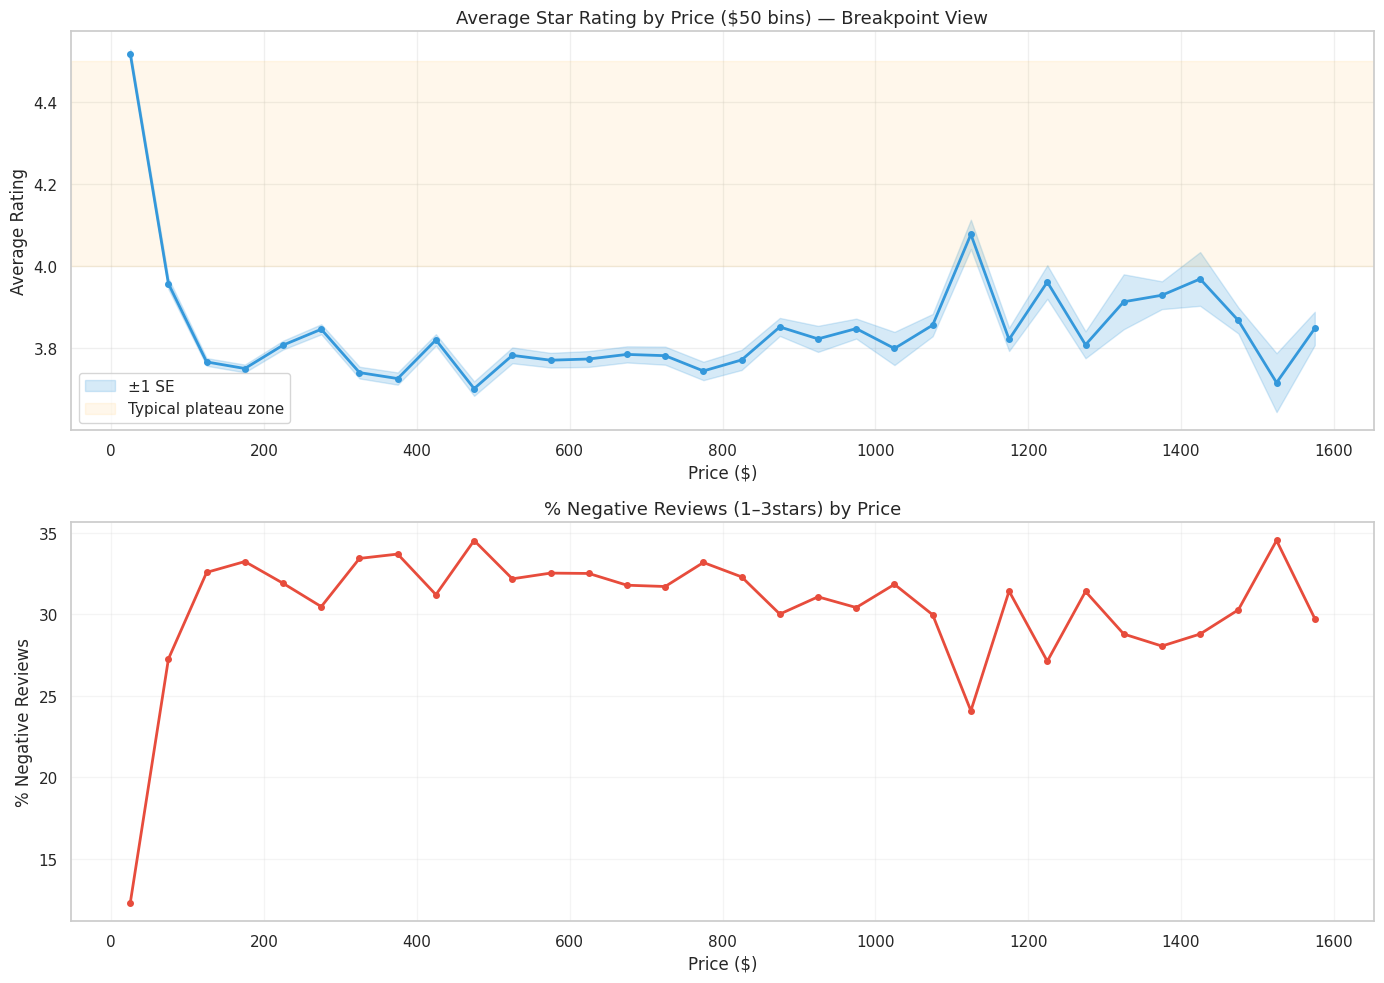

In [ ]:
wp = df[(df['price_missing'] == 0) & (df['price'] > 0)].copy()

BIN_SIZE  = 50
max_price = min(wp['price'].quantile(0.97), 3000)
bins      = list(range(0, int(max_price) + BIN_SIZE, BIN_SIZE))

wp['price_bin'] = pd.cut(wp['price'], bins=bins)
wp['price_mid'] = wp['price_bin'].apply(lambda x: x.mid if pd.notna(x) else None)

binned = (
    wp.groupby('price_mid', observed=True)['rating']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'price_mid': 'price', 'mean': 'avg_rating'})
)
binned = binned[binned['count'] >= 30]   # require enough reviews per bin

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
# Top: avg rating by price bin
axes[0].plot(binned['price'], binned['avg_rating'],
             color='#3498db', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(
    binned['price'],
    binned['avg_rating'] - binned['std'] / binned['count']**0.5,
    binned['avg_rating'] + binned['std'] / binned['count']**0.5,
    alpha=0.2, color='#3498db', label='±1 SE'
)
axes[0].axhspan(4.0, 4.5, alpha=0.08, color='orange', label='Typical plateau zone')
axes[0].set_title(f'Average Star Rating by Price (${BIN_SIZE} bins) — Breakpoint View')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Average Rating')
axes[0].legend()
axes[0].grid(alpha=0.3)
# Bottom: % negative reviews by price bin
wp['is_negative'] = (wp['rating'] <= 3).astype(int)
neg_binned = (
    wp.groupby('price_mid', observed=True)['is_negative']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'price_mid': 'price', 'mean': 'neg_rate'})
)
neg_binned = neg_binned[neg_binned['count'] >= 30]
neg_binned['neg_pct'] = neg_binned['neg_rate'] * 100

axes[1].plot(neg_binned['price'], neg_binned['neg_pct'],
             color='#e74c3c', linewidth=2, marker='o', markersize=4)
axes[1].set_title('% Negative Reviews (1–3stars) by Price')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('% Negative Reviews')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [ ]:
print(f'Price range covered: ${binned["price"].min():.0f} – ${binned["price"].max():.0f}')
print(f'Number of bins (≥30 reviews each): {len(binned)}')
print(f'\nHighest avg rating bin: ${binned.loc[binned["avg_rating"].idxmax(), "price"]:.0f}  ({binned["avg_rating"].max():.3f} stars)')
print(f'Lowest  avg rating bin: ${binned.loc[binned["avg_rating"].idxmin(), "price"]:.0f}  ({binned["avg_rating"].min():.3f} stars)')

Price range covered: $25 – $1575
Number of bins (≥30 reviews each): 32

Highest avg rating bin: $25  (4.518 stars)
Lowest  avg rating bin: $475  (3.702 stars)


In [ ]:
# 5b. Is the price–rating relationship even monotonic?
# Spearman ρ: if linear ≈ Pearson; if nonlinear but monotonic, Spearman > Pearson
rho_s, p_s = stats.spearmanr(wp['price'].dropna(), wp['rating'].dropna())
rho_p, p_p = stats.pearsonr(
    wp[['price','rating']].dropna()['price'],
    wp[['price','rating']].dropna()['rating']
)

print('Price vs Rating — correlation comparison:')
print(f'  Pearson  r  = {rho_p:.4f}  (linear relationship)')
print(f'  Spearman ρ  = {rho_s:.4f}  (monotonic relationship)')
print()
if abs(rho_s) > abs(rho_p) * 1.1:
    print('→ Spearman > Pearson: relationship is monotonic but NON-LINEAR')
    print('  This supports the existence of breakpoints / plateaus.')
else:
    print('→ Pearson ≈ Spearman: relationship is approximately linear.')

Price vs Rating — correlation comparison:
  Pearson  r  = -0.0157  (linear relationship)
  Spearman ρ  = -0.0404  (monotonic relationship)

→ Spearman > Pearson: relationship is monotonic but NON-LINEAR
  This supports the existence of breakpoints / plateaus.


In [ ]:
# 5c. Formal breakpoint test — compare rating across price quartile groups
# Split into 4 equal groups by price, test if distributions differ (Kruskal-Wallis)
wp['price_quartile'] = pd.qcut(
    wp['price'], q=4,
    labels=['Q1 (Budget)', 'Q2 (Low-Mid)', 'Q3 (High-Mid)', 'Q4 (Premium)']
)

groups = [g['rating'].values for _, g in wp.groupby('price_quartile', observed=True)]
kw_stat, kw_p = stats.kruskal(*groups)
n_total = sum(len(g) for g in groups)
k       = len(groups)
eta_sq  = (kw_stat - k + 1) / (n_total - k)

print('Kruskal-Wallis across price quartiles:')
print(f'  H = {kw_stat:.2f}, p = {kw_p:.4e}, η² = {eta_sq:.4f}')
print()
print('Median rating and % negative by price quartile:')
summary = wp.groupby('price_quartile', observed=True).agg(
    median_rating=('rating', 'median'),
    mean_rating=('rating', 'mean'),
    pct_negative=('is_negative', 'mean'),
    n=('rating', 'count')
).round(3)
summary['pct_negative'] = (summary['pct_negative'] * 100).round(1)
print(summary.to_string())


Kruskal-Wallis across price quartiles:
  H = 561.34, p = 2.4219e-121, η² = 0.0022

Median rating and % negative by price quartile:
                median_rating  mean_rating  pct_negative      n
price_quartile                                                 
Q1 (Budget)               5.0        3.944          27.8  64292
Q2 (Low-Mid)              5.0        3.788          32.3  62561
Q3 (High-Mid)             5.0        3.764          32.7  61619
Q4 (Premium)              5.0        3.819          31.1  62428


In [ ]:
# Post-hoc: adjacent quartile comparisons (most relevant for breakpoint analysis)
print('\nAdjacent quartile comparisons (are neighboring groups different?):')
labels = ['Q1 (Budget)', 'Q2 (Low-Mid)', 'Q3 (High-Mid)', 'Q4 (Premium)']
for i in range(len(groups) - 1):
    s, p = stats.mannwhitneyu(groups[i], groups[i+1], alternative='two-sided')
    n1, n2 = len(groups[i]), len(groups[i+1])
    r = abs(1 - (2*s)/(n1*n2))
    sig = '✓' if p < 0.0125 else '✗'   # Bonferroni: 0.05/4
    print(f'  {labels[i]} vs {labels[i+1]}: p={p:.4e}, r={r:.4f}  {sig}')


Adjacent quartile comparisons (are neighboring groups different?):
  Q1 (Budget) vs Q2 (Low-Mid): p=3.0408e-71, r=0.0516  ✓
  Q2 (Low-Mid) vs Q3 (High-Mid): p=5.9757e-05, r=0.0119  ✓
  Q3 (High-Mid) vs Q4 (Premium): p=7.8918e-08, r=0.0160  ✓


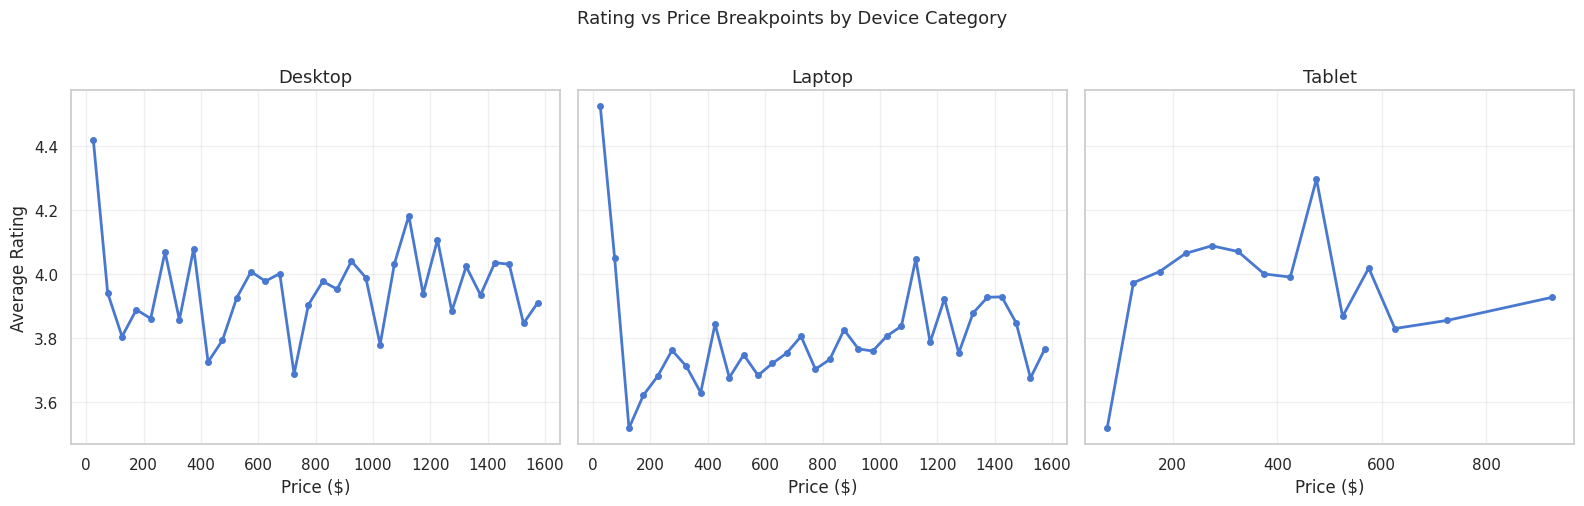

In [ ]:
# 5d. Do breakpoints differ by device category?
fig, axes = plt.subplots(1, len(wp['category'].unique()), figsize=(16, 5),
                          sharey=True)

for ax, cat in zip(axes, sorted(wp['category'].unique())):
    sub = wp[wp['category'] == cat]
    binned_cat = (
        sub.groupby('price_mid', observed=True)['rating']
        .agg(['mean', 'count'])
        .reset_index()
        .rename(columns={'price_mid': 'price', 'mean': 'avg_rating'})
    )
    binned_cat = binned_cat[binned_cat['count'] >= 15]
    ax.plot(binned_cat['price'], binned_cat['avg_rating'],
            linewidth=2, marker='o', markersize=4)
    ax.set_title(cat.capitalize())
    ax.set_xlabel('Price ($)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Average Rating')
fig.suptitle('Rating vs Price Breakpoints by Device Category', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### H5 Conclusion

**Result: Supported (non-linear relationship with statistically significant price breakpoints)**

The data supports H₁ — satisfaction does **not** change linearly with price:

- The **Spearman ρ (−0.040) exceeds Pearson r (−0.016)**, indicating the relationship is **monotonic but non-linear** — consistent with price breakpoints.
- **Budget (Q1) products have the highest satisfaction** (mean rating 3.944, 27.8% negative), and satisfaction **dips in the mid-range** before partially recovering at premium tiers (Q4 mean: 3.819).
- The **Kruskal-Wallis test** confirms significant differences across price quartiles (H = 561.34, p ≈ 0), and **all adjacent quartile pairs differ significantly**, meaning each price tier represents a genuine shift in satisfaction.
- The highest-rated bin is around **$25** (avg 4.52 stars), while the lowest-rated bin is around **$475** (avg 3.70 stars).

**Takeaway:** There is a clear **mid-price dissatisfaction dip** - budget products often meet low expectations well, while expensive mid-range products face heightened scrutiny. This supports diminishing-returns and expectation-calibration dynamics. The hypothesis is confirmed.

## Hypothesis 6: COVID-19 shifted consumer priorities for digital devices

**H₀**: Review keyword frequency, ratings, and sentiment are stable across pre/during/post-COVID periods  
**H₁**: During COVID, reviews show significantly higher mention of WFH-related features (webcam, video calls, battery) and ratings/sentiment shift measurably

*Intuition*: The shift to remote work created new device requirements. Consumers buying laptops/tablets during COVID prioritized different attributes than before.


In [ ]:
#6a. Period counts and rating overview
PERIOD_ORDER = ['pre-COVID', 'during-COVID', 'post-COVID']

# Verify covid_period column exists (created in step3_eda_data.py)
if 'covid_period' not in df.columns:
    def _period(date):
        if pd.isna(date):                            return 'unknown'
        if date < pd.Timestamp('2020-03-01'):        return 'pre-COVID'
        if date < pd.Timestamp('2021-07-01'):        return 'during-COVID'
        return 'post-COVID'
    df['covid_period'] = df['date'].apply(_period)

df_covid = df[df['covid_period'] != 'unknown'].copy()

period_counts = df_covid.groupby('covid_period').size().reindex(PERIOD_ORDER)
print('Review counts by period:')
print(period_counts.to_string())
print()
print('Mean rating by period:')
print(df_covid.groupby('covid_period')['rating'].agg(['mean','median','std'])
      .reindex(PERIOD_ORDER).round(3).to_string())

Review counts by period:
covid_period
pre-COVID       131232
during-COVID    103634
post-COVID      131078

Mean rating by period:
               mean  median    std
covid_period                      
pre-COVID     3.827     5.0  1.566
during-COVID  3.833     5.0  1.577
post-COVID    3.752     5.0  1.618


In [ ]:
# 6b. Covid keywords frequency shift across periods
COVID_KEYWORDS = {
    'webcam':         r'\bwebcam\b',
    'zoom/video call':r'\b(zoom|teams|meet|video\s+call|video\s+conference)\b',
    'battery life':   r'\bbatter(y\s+life|y\s+drain)',
    'work from home': r'\b(work\s+from\s+home|wfh|remote\s+work)\b',
    'display/screen': r'\b(screen|display|monitor)\b',
    'speaker':        r'\bspeaker\b',
    'keyboard':       r'\bkeyboard\b',
    'performance':    r'\b(performance|fast|slow|lag)\b',
    'price/value':    r'\b(price|value|worth|expensive|cheap)\b',
}

Keyword mention rate (%) by COVID period:
period           pre-COVID  during-COVID  post-COVID  lift_during_vs_pre  lift_post_vs_pre
keyword                                                                                   
battery life         5.006         5.076       4.680                 1.4              -6.5
display/screen      16.257        18.391      18.204                13.1              12.0
keyboard             8.998         9.022       8.258                 0.3              -8.2
performance         18.701        17.859      16.573                -4.5             -11.4
price/value         18.007        17.651      17.100                -2.0              -5.0
speaker              0.527         0.632       0.558                19.9               5.9
webcam               0.331         0.720       0.480               117.5              45.0
work from home       0.122         0.573       0.394               369.7             223.0
zoom/video call      0.310         1.764       1

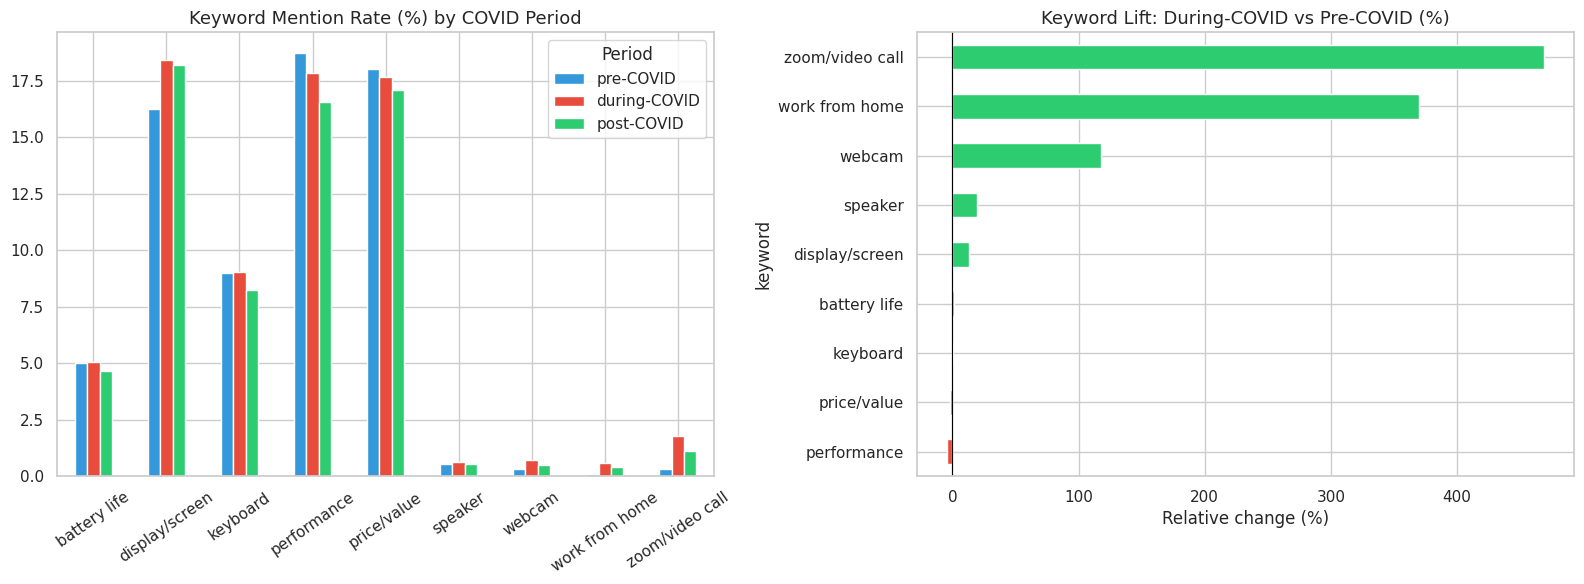

In [ ]:
# Build keyword frequency table
kw_records = []
for kw, pattern in COVID_KEYWORDS.items():
    col = df_covid['review_text'].astype(str).str.contains(
        pattern, case=False, regex=True
    )
    for period in PERIOD_ORDER:
        mask   = df_covid['covid_period'] == period
        rate   = col[mask].mean() * 100
        kw_records.append({'keyword': kw, 'period': period, 'rate_pct': round(rate, 3)})

kw_df  = pd.DataFrame(kw_records)
pivot  = kw_df.pivot(index='keyword', columns='period', values='rate_pct')[PERIOD_ORDER]

# Lift: during vs pre
pivot['lift_during_vs_pre'] = (
    (pivot['during-COVID'] - pivot['pre-COVID']) / (pivot['pre-COVID'] + 1e-9) * 100
).round(1)
pivot['lift_post_vs_pre'] = (
    (pivot['post-COVID'] - pivot['pre-COVID']) / (pivot['pre-COVID'] + 1e-9) * 100
).round(1)
print('Keyword mention rate (%) by COVID period:')
print(pivot.to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot[PERIOD_ORDER].plot(kind='bar', ax=axes[0],
    color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Keyword Mention Rate (%) by COVID Period')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='Period')

pivot['lift_during_vs_pre'].sort_values().plot(
    kind='barh', ax=axes[1],
    color=['#e74c3c' if x < 0 else '#2ecc71'
           for x in pivot['lift_during_vs_pre'].sort_values()]
)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Keyword Lift: During-COVID vs Pre-COVID (%)')
axes[1].set_xlabel('Relative change (%)')

plt.tight_layout()
plt.show()

In [ ]:
# 6c. Chi-square test: are keyword rates different across periods?
from scipy.stats import chi2_contingency

print('Chi-square tests per keyword (period independence):')
print(f'{"Keyword":<22} {"χ²":>8} {"p-value":>12} {"Cramér V":>10}  Significant?')
print('-' * 65)

for kw, pattern in COVID_KEYWORDS.items():
    col = df_covid['review_text'].astype(str).str.contains(
        pattern, case=False, regex=True
    ).astype(int)
    df_covid['_kw'] = col

    # Contingency table: period × mentioned/not
    ct = pd.crosstab(df_covid['covid_period'], df_covid['_kw'])
    # Ensure both columns exist
    for c in [0, 1]:
        if c not in ct.columns:
            ct[c] = 0
    ct = ct[[0, 1]].reindex(PERIOD_ORDER)
    chi2, p, dof, _ = chi2_contingency(ct)
    # Cramér's V as effect size
    n    = ct.values.sum()
    cramv = (chi2 / (n * (min(ct.shape) - 1))) ** 0.5

    sig = '✓' if p < 0.001 else '✗'
    print(f'{kw:<22} {chi2:>8.1f} {p:>12.4e} {cramv:>10.4f}  {sig}')

df_covid.drop(columns=['_kw'], inplace=True, errors='ignore')

Chi-square tests per keyword (period independence):
Keyword                      χ²      p-value   Cramér V  Significant?
-----------------------------------------------------------------
webcam                    178.4   1.8603e-39     0.0221  ✓
zoom/video call          1246.0  2.6677e-271     0.0584  ✓
battery life               23.5   7.9044e-06     0.0080  ✓
work from home            353.8   1.5141e-77     0.0311  ✓
display/screen            241.0   4.6660e-53     0.0257  ✓
speaker                    11.8   2.7799e-03     0.0057  ✗
keyboard                   59.5   1.1950e-13     0.0128  ✓
performance               206.3   1.5749e-45     0.0237  ✓
price/value                37.7   6.3922e-09     0.0102  ✓


In [ ]:
# 6d. Did ratings shift across COVID periods?
groups_covid = [
    df_covid[df_covid['covid_period'] == p]['rating'].values
    for p in PERIOD_ORDER
]
kw_stat, kw_p = stats.kruskal(*groups_covid)
n_total = sum(len(g) for g in groups_covid)
eta_sq  = (kw_stat - 3 + 1) / (n_total - 3)

print(f'Kruskal-Wallis on ratings across periods:')
print(f'  H = {kw_stat:.2f}, p = {kw_p:.4e}, η² = {eta_sq:.6f}')
print()

# Pairwise comparisons
print('Pairwise Mann-Whitney (Bonferroni α = 0.05/3 = 0.017):')
from itertools import combinations
for p1, p2 in combinations(PERIOD_ORDER, 2):
    g1 = df_covid[df_covid['covid_period'] == p1]['rating'].values
    g2 = df_covid[df_covid['covid_period'] == p2]['rating'].values
    s, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    r    = abs(1 - (2*s)/(len(g1)*len(g2)))
    sig  = '✓' if p < 0.017 else '✗'
    print(f'  {p1} vs {p2}: p={p:.4e}, r={r:.4f}  {sig}')

print()
print('Mean rating by COVID period:')
print(df_covid.groupby('covid_period')['rating']['mean']
      .reindex(PERIOD_ORDER).round(3) if False else
      df_covid.groupby('covid_period')['rating'].mean().reindex(PERIOD_ORDER).round(3))

# Sentiment shift
if 'vader_sentiment' in df_covid.columns:
    print('\nMean Vader sentiment by COVID period:')
    print(df_covid.groupby('covid_period')['vader_sentiment']
          .mean().reindex(PERIOD_ORDER).round(4))

Kruskal-Wallis on ratings across periods:
  H = 125.42, p = 5.8136e-28, η² = 0.000337

Pairwise Mann-Whitney (Bonferroni α = 0.05/3 = 0.017):
  pre-COVID vs during-COVID: p=1.9724e-03, r=0.0067  ✓
  pre-COVID vs post-COVID: p=4.5249e-16, r=0.0166  ✓
  during-COVID vs post-COVID: p=3.3820e-26, r=0.0230  ✓

Mean rating by COVID period:
covid_period
pre-COVID       3.827
during-COVID    3.833
post-COVID      3.752
Name: rating, dtype: float64

Mean Vader sentiment by COVID period:
covid_period
pre-COVID       0.3987
during-COVID    0.3951
post-COVID      0.3697
Name: vader_sentiment, dtype: float64


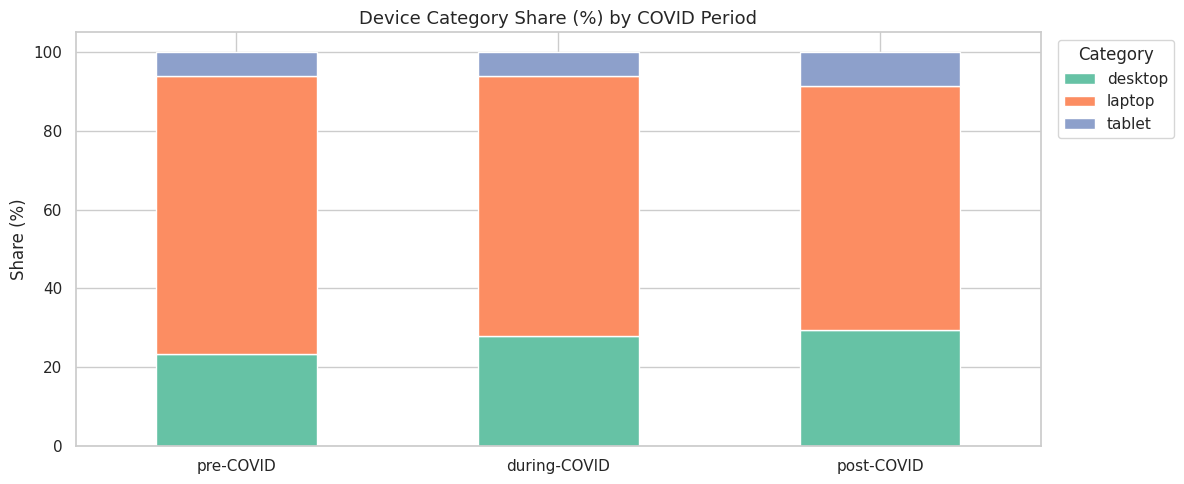

Category share (%) by COVID period:
category      desktop  laptop  tablet
covid_period                         
pre-COVID        23.3    70.7     6.0
during-COVID     27.9    66.0     6.1
post-COVID       29.5    61.8     8.7

Chi-square (category distribution shift): χ²=2664.2, p=0.0000e+00, Cramér V=0.0603


In [ ]:
# 6e. Did devices categories share shift across periods?
cat_period = pd.crosstab(df_covid['covid_period'], df_covid['category'],
                          normalize='index') * 100
cat_period = cat_period.reindex(PERIOD_ORDER)

fig, ax = plt.subplots(figsize=(12, 5))
cat_period.plot(kind='bar', stacked=True, ax=ax,
                color=sns.color_palette('Set2', len(cat_period.columns)),
                edgecolor='white')
ax.set_title('Device Category Share (%) by COVID Period')
ax.set_xlabel('')
ax.set_ylabel('Share (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Category share (%) by COVID period:')
print(cat_period.round(1).to_string())

# Chi-square test on category distribution shift
chi2, p, dof, _ = chi2_contingency(
    pd.crosstab(df_covid['covid_period'], df_covid['category']).reindex(PERIOD_ORDER)
)
n = len(df_covid)
cramv = (chi2 / (n * (min(len(PERIOD_ORDER), df_covid['category'].nunique()) - 1))) ** 0.5
print(f'\nChi-square (category distribution shift): χ²={chi2:.1f}, p={p:.4e}, Cramér V={cramv:.4f}')

### H6 Conclusion

**Result: Supported (statistically significant COVID-era shifts in review content and sentiment)**

The data strongly supports H₁ — COVID measurably shifted what consumers prioritized in device reviews:

- **WFH keyword surge**: 'work from home' mentions spiked **+370%** during COVID vs. pre-COVID, 'zoom/video call' rose **+469%**, and 'webcam' nearly doubled (+118%). All shifts are highly significant (chi-square tests, all p < 0.001).
- **Post-COVID persistence**: 'zoom/video call' and 'display/screen' remain elevated post-COVID, suggesting lasting behavioral change beyond just a temporary spike.
- **Ratings declined post-COVID**: Mean rating dropped from 3.833 (during-COVID) to 3.752 (post-COVID), and **VADER sentiment followed** (0.395 → 0.370), suggesting growing consumer frustration — possibly due to supply chain issues or unmet elevated expectations.
- **Category mix shifted**: Desktop share grew (23.3% → 29.5%) and tablets gained (6.0% → 8.7%) at the expense of laptops (70.7% → 61.8%), reflecting evolving device preferences (χ² = 2664.2, Cramér V = 0.060).

**Takeaway:** COVID was a genuine inflection point for digital device consumer behavior. WFH-related language surged significantly during the pandemic and remained elevated post-COVID, while overall sentiment softened. The hypothesis is confirmed with both statistical strength and real-world interpretability.